# 원의 방정식

**표준형** (중심 $(a,b)$, 반지름 $r$)

$$
(x-a)^2 + (y-b)^2 = r^2
$$

**일반형**

$$
x^2 + y^2 + Dx + Ey + F = 0
$$

(완전제곱으로 표준형으로 고칠 수 있다. 단 $D^2+E^2-4F>0$일 때 실원.)


## 1. 표준형 → 중심·반지름


표준형: (x-2)^2 + (y-3)^2 = 5^2
중심: (2, 3), 반지름: 5


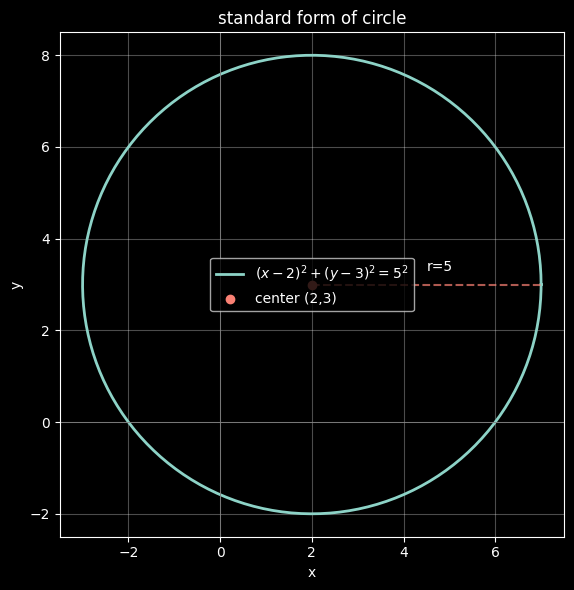

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

sp.init_printing()

# 중심 (h,k), 반지름 r
h, k, r = 2, 3, 5
print(f"표준형: (x-{h})^2 + (y-{k})^2 = {r}^2")
print(f"중심: ({h}, {k}), 반지름: {r}")

theta = np.linspace(0, 2*np.pi, 300)
cx = h + r*np.cos(theta)
cy = k + r*np.sin(theta)

plt.figure(figsize=(6, 6))
plt.plot(cx, cy, color='C0', lw=2, label=rf'$(x-{h})^2+(y-{k})^2={r}^2$')
plt.scatter([h], [k], color='C3', zorder=5, label=f'center ({h},{k})')
plt.plot([h, h+r], [k, k], 'C3--', alpha=0.7)
plt.text(h + r/2, k + 0.3, f'r={r}')
plt.gca().set_aspect('equal', adjustable='box')
plt.axhline(0, color='gray', lw=0.6); plt.axvline(0, color='gray', lw=0.6)
plt.xlabel('x'); plt.ylabel('y')
plt.title('standard form of circle')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**매개변수**: $x=a+r\cos\theta$, $y=b+r\sin\theta$ <br>
=> 원을 그릴 때 편리


## 2. 일반형 → 표준형


In [2]:
x, y = sp.symbols('x y')
# 예: x^2 + y^2 - 4x + 6y - 3 = 0
D, E, F = -4, 6, -3
gen = x**2 + y**2 + D*x + E*y + F

# 완전제곱 → 중심·반지름
a_c = -D / 2
b_c = -E / 2
r2 = a_c**2 + b_c**2 - F
print("일반형:")
display(sp.Eq(gen, 0))
print(f"중심: ({a_c}, {b_c}),  r^2 = {r2},  r = {sp.sqrt(r2)}")


일반형:


중심: (2.0, -3.0),  r^2 = 16.0,  r = 4.00000000000000


**완전제곱**: <br>
=> $x^2+Dx=(x+D/2)^2-(D/2)^2$ 등으로 중심·반지름 추출

중심 $\left(-\dfrac{D}{2}, -\dfrac{E}{2}\right)$,  
$r=\sqrt{\left(\dfrac{D}{2}\right)^2+\left(\dfrac{E}{2}\right)^2-F}$


## 3. 원과 직선의 위치 관계 ($d$ vs $r$)

중심에서 직선까지의 거리를 $d$, 반지름을 $r$이라 할 때:

| 관계 | 의미 |
|------|------|
| $d < r$ | 두 점에서 만날 때 |
| $d = r$ | 접할 때 |
| $d > r$ | 만나지 않을 때 |


In [3]:
def point_line_distance(x0, y0, a, b, c):
    return np.abs(a*x0 + b*y0 + c) / np.sqrt(a**2 + b**2)

def classify(d, r):
    if np.isclose(d, r):
        return "접할 때 (d = r)"
    if d < r:
        return "두 점에서 만날 때 (d < r)"
    return "만나지 않을 때 (d > r)"

# 공통 원: 중심 (2,3), r=5
center = (h, k)
# 세 직선 예
lines = [
    (1, 0, -2),    # x=2 (거의 지름에 가깝게 가로지름) → d 작음
    (3, -4, -7),   # 접선이 되도록 조정 가능
    (0, 1, 10),    # y=-10 → 멀리
]

print(f"원: 중심 {center}, r={r}\n")
for a, b, c in lines:
    d = point_line_distance(center[0], center[1], a, b, c)
    print(f"직선 {a}x+({b})y+{c}=0  →  d={d:.4f}  →  {classify(d, r)}")


원: 중심 (2, 3), r=5

직선 1x+(0)y+-2=0  →  d=0.0000  →  두 점에서 만날 때 (d < r)
직선 3x+(-4)y+-7=0  →  d=2.6000  →  두 점에서 만날 때 (d < r)
직선 0x+(1)y+10=0  →  d=13.0000  →  만나지 않을 때 (d > r)


## 4. 세 경우 시각화


/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_96611/731183457.py:28: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_96611/731183457.py:28: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_96611/731183457.py:28: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_96611/731183457.py:28: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_96611/731183457.py:28: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/v

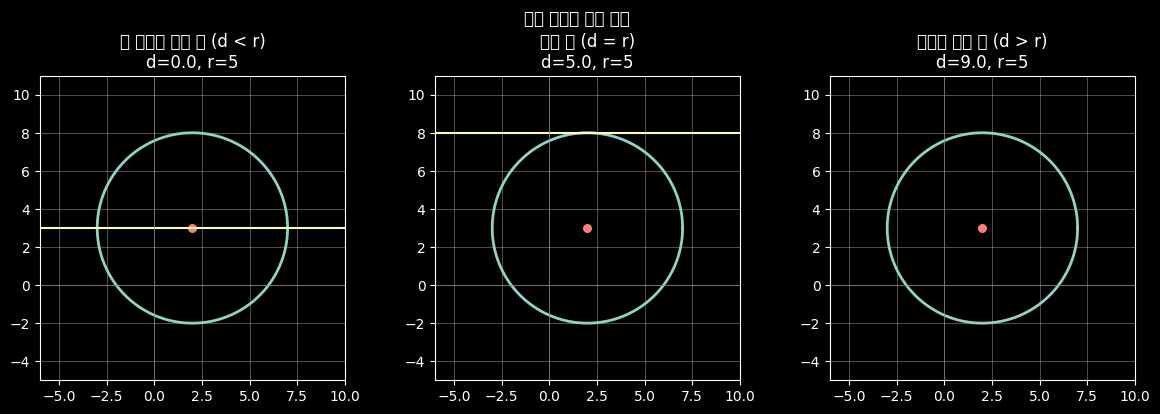

In [4]:
# 세 직선을 d<r, d=r, d>r 이 되도록 구성
# 원 중심 (2,3), r=5
cases = [
    ("두 점에서 만날 때 (d < r)", (0, 1, -3)),   # y=3, d=0 < 5
    ("접할 때 (d = r)", (0, 1, -8)),             # y=8, d=|3-8|=5 = r
    ("만나지 않을 때 (d > r)", (0, 1, -12)),     # y=12, d=9 > 5
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
theta = np.linspace(0, 2*np.pi, 300)
for ax, (title, (a, b, c)) in zip(axes, cases):
    d = point_line_distance(h, k, a, b, c)
    ax.plot(h + r*np.cos(theta), k + r*np.sin(theta), 'C0', lw=2)
    ax.scatter([h], [k], color='C3', s=30)
    xs = np.linspace(h - 8, h + 8, 200)
    if abs(b) > 1e-12:
        ys = -(a*xs + c) / b
        ax.plot(xs, ys, 'C1', lw=1.5)
    else:
        ax.axvline(-c/a, color='C1', lw=1.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(h-8, h+8); ax.set_ylim(k-8, k+8)
    ax.set_title(f"{title}\nd={d:.1f}, r={r}")
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

plt.suptitle('원과 직선의 위치 관계')
plt.tight_layout(); plt.show()
